# 06. Нейронна мережа

На цьому етапі будується нейронна мережа для прогнозування
цільової змінної `calories_burned`.

Модель реалізується з використанням PyTorch.

Основні завдання:

- підготовка даних для PyTorch;
- перевірка доступності GPU;
- побудова архітектури нейронної мережі;
- навчання моделі;
- оцінювання якості прогнозування;
- порівняння результатів із класичними регресійними моделями.

In [1]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import sys
import importlib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0+cu128


In [2]:
# ============================================================
# CONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=False
)

Mounted at /content/drive


In [3]:
# ============================================================
# LOAD PROJECT
# ============================================================

PROJECT_DIR = "/content/drive/MyDrive/FitnessML_Master"

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

importlib.invalidate_caches()

print("✓ Project connected")
print(PROJECT_DIR)

✓ Project connected
/content/drive/MyDrive/FitnessML_Master


In [4]:
# ============================================================
# IMPORT PROJECT MODULES
# ============================================================

import config
import utils

config = importlib.reload(config)
utils = importlib.reload(utils)

utils.section("Project modules")

print("✓ config.py loaded")
print("✓ utils.py loaded")


PROJECT MODULES
✓ config.py loaded
✓ utils.py loaded


In [5]:
# ============================================================
# HARDWARE CHECK
# ============================================================

utils.section("Hardware check")

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"PyTorch device: {device}")

if torch.cuda.is_available():

    print(
        f"GPU: {torch.cuda.get_device_name(0)}"
    )

    gpu_memory = (
        torch.cuda.get_device_properties(0)
        .total_memory / 1024**3
    )

    print(
        f"VRAM: {gpu_memory:.2f} GB"
    )

else:

    print("GPU not available")
    print("Training will use CPU.")


HARDWARE CHECK
PyTorch device: cuda
GPU: Tesla T4
VRAM: 14.56 GB


# Завантаження підготовлених даних

Для нейронної мережі використовується набір даних після
Feature Engineering.

Використовується 18 вхідних ознак, сформованих на етапі `04`.

Цільовою змінною залишається `calories_burned`.

In [6]:
# ============================================================
# LOAD ENGINEERED DATA
# ============================================================

utils.section("Engineered dataset")

X_train = pd.read_csv(
    config.TABLES_DIR / "04_X_train_engineered.csv"
)

X_valid = pd.read_csv(
    config.TABLES_DIR / "04_X_valid_engineered.csv"
)

X_test = pd.read_csv(
    config.TABLES_DIR / "04_X_test_engineered.csv"
)

y_train = pd.read_csv(
    config.TABLES_DIR / "03_y_train.csv"
)["calories_burned"]

y_valid = pd.read_csv(
    config.TABLES_DIR / "03_y_valid.csv"
)["calories_burned"]

y_test = pd.read_csv(
    config.TABLES_DIR / "03_y_test.csv"
)["calories_burned"]

print(f"Train      : {X_train.shape}")
print(f"Validation : {X_valid.shape}")
print(f"Test       : {X_test.shape}")


ENGINEERED DATASET
Train      : (292000, 18)
Validation : (36500, 18)
Test       : (36500, 18)


In [7]:
# ============================================================
# DATA VALIDATION
# ============================================================

utils.section("Data validation")

assert X_train.shape[0] == y_train.shape[0]
assert X_valid.shape[0] == y_valid.shape[0]
assert X_test.shape[0] == y_test.shape[0]

assert list(X_train.columns) == list(X_valid.columns)
assert list(X_train.columns) == list(X_test.columns)

assert "calories_burned" not in X_train.columns

print("✓ Feature matrices are consistent")
print("✓ Target variable is separated")
print("✓ Train / validation / test dimensions are valid")
print(f"✓ Number of features: {X_train.shape[1]}")


DATA VALIDATION
✓ Feature matrices are consistent
✓ Target variable is separated
✓ Train / validation / test dimensions are valid
✓ Number of features: 18


In [8]:
# ============================================================
# CONVERT TO NUMPY
# ============================================================

X_train_np = X_train.to_numpy(
    dtype=np.float32
)

X_valid_np = X_valid.to_numpy(
    dtype=np.float32
)

X_test_np = X_test.to_numpy(
    dtype=np.float32
)

y_train_np = y_train.to_numpy(
    dtype=np.float32
)

y_valid_np = y_valid.to_numpy(
    dtype=np.float32
)

y_test_np = y_test.to_numpy(
    dtype=np.float32
)

print("✓ Data converted to float32")

✓ Data converted to float32


In [9]:
# ============================================================
# CREATE PYTORCH TENSORS
# ============================================================

X_train_tensor = torch.tensor(
    X_train_np,
    dtype=torch.float32
)

X_valid_tensor = torch.tensor(
    X_valid_np,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_np,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_np,
    dtype=torch.float32
).view(-1, 1)

y_valid_tensor = torch.tensor(
    y_valid_np,
    dtype=torch.float32
).view(-1, 1)

y_test_tensor = torch.tensor(
    y_test_np,
    dtype=torch.float32
).view(-1, 1)

print("✓ PyTorch tensors created")

print(
    f"Input shape: {X_train_tensor.shape}"
)

print(
    f"Target shape: {y_train_tensor.shape}"
)

✓ PyTorch tensors created
Input shape: torch.Size([292000, 18])
Target shape: torch.Size([292000, 1])


In [10]:
# ============================================================
# CREATE DATA LOADERS
# ============================================================

utils.section("Data loaders")

BATCH_SIZE = 1024

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

valid_dataset = TensorDataset(
    X_valid_tensor,
    y_valid_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Batch size: {BATCH_SIZE}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")


DATA LOADERS
Batch size: 1024
Training batches: 286
Validation batches: 36
Test batches: 36


In [11]:
# ============================================================
# CHECK TRAINING BATCH
# ============================================================

X_batch, y_batch = next(iter(train_loader))

print("Input batch shape :", X_batch.shape)
print("Target batch shape:", y_batch.shape)

Input batch shape : torch.Size([1024, 18])
Target batch shape: torch.Size([1024, 1])


# Архітектура нейронної мережі

Для прогнозування цільової змінної використовується багатошаровий
перцептрон (MLP).

Архітектура моделі складається з трьох прихованих шарів:

- 64 нейрони;
- 32 нейрони;
- 16 нейронів.

Для нелінійної активації використовується ReLU.
Dropout застосовується для зменшення ризику перенавчання.

Вихідний шар містить один нейрон, оскільки задача є регресійною.

In [12]:
# ============================================================
# NEURAL NETWORK ARCHITECTURE
# ============================================================

utils.section("Neural network architecture")


class FitnessMLNet(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


input_size = X_train.shape[1]

model = FitnessMLNet(
    input_size=input_size
).to(device)

print(model)


NEURAL NETWORK ARCHITECTURE
FitnessMLNet(
  (network): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [13]:
# ============================================================
# MODEL DEVICE CHECK
# ============================================================

print(
    "Model device:",
    next(model.parameters()).device
)

print(
    "Input features:",
    input_size
)

Model device: cuda:0
Input features: 18


# Функція втрат та оптимізатор

Для навчання регресійної моделі використовується Mean Squared Error (MSE)
як функція втрат.

Для оптимізації параметрів нейронної мережі використовується алгоритм Adam.

In [14]:
# ============================================================
# LOSS FUNCTION AND OPTIMIZER
# ============================================================

utils.section("Loss function and optimizer")

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("✓ Loss function: MSELoss")
print("✓ Optimizer: Adam")
print("✓ Learning rate: 0.001")


LOSS FUNCTION AND OPTIMIZER
✓ Loss function: MSELoss
✓ Optimizer: Adam
✓ Learning rate: 0.001


In [15]:
# ============================================================
# TRAINING SETTINGS
# ============================================================

EPOCHS = 30

print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Device: {device}")

Epochs: 30
Batch size: 1024
Device: cuda


# Навчання нейронної мережі

Модель навчається протягом заданої кількості епох.

Для кожної епохи обчислюються середні значення функції втрат
на тренувальній та валідаційній вибірках.

Збереження обох показників дозволяє контролювати процес навчання
та виявляти ознаки перенавчання.

In [16]:
# ============================================================
# TRAINING LOOP
# ============================================================

utils.section("Neural network training")

train_losses = []
valid_losses = []

for epoch in range(EPOCHS):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    model.train()

    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(
            predictions,
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_loss += (
            loss.item() * X_batch.size(0)
        )

    train_loss /= len(train_loader.dataset)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    model.eval()

    valid_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in valid_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            valid_loss += (
                loss.item() * X_batch.size(0)
            )

    valid_loss /= len(valid_loader.dataset)

    # --------------------------------------------------------
    # Store losses
    # --------------------------------------------------------

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    # --------------------------------------------------------
    # Progress
    # --------------------------------------------------------

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {valid_loss:.4f}"
    )


NEURAL NETWORK TRAINING
Epoch 01/30 | Train Loss: 2514763.9101 | Validation Loss: 497204.1434
Epoch 02/30 | Train Loss: 413328.5156 | Validation Loss: 248941.0876
Epoch 03/30 | Train Loss: 243730.6783 | Validation Loss: 137782.3930
Epoch 04/30 | Train Loss: 174132.9543 | Validation Loss: 102199.7244
Epoch 05/30 | Train Loss: 154711.7304 | Validation Loss: 95208.6285
Epoch 06/30 | Train Loss: 149115.3933 | Validation Loss: 92448.1780
Epoch 07/30 | Train Loss: 146011.4002 | Validation Loss: 91903.9942
Epoch 08/30 | Train Loss: 144944.7907 | Validation Loss: 91439.9191
Epoch 09/30 | Train Loss: 143829.0005 | Validation Loss: 91239.7508
Epoch 10/30 | Train Loss: 142011.1472 | Validation Loss: 91042.0731
Epoch 11/30 | Train Loss: 141912.5023 | Validation Loss: 90837.2312
Epoch 12/30 | Train Loss: 141381.6473 | Validation Loss: 90807.1705
Epoch 13/30 | Train Loss: 140753.3869 | Validation Loss: 90529.6070
Epoch 14/30 | Train Loss: 141220.4985 | Validation Loss: 90434.8581
Epoch 15/30 | Trai


TRAINING HISTORY


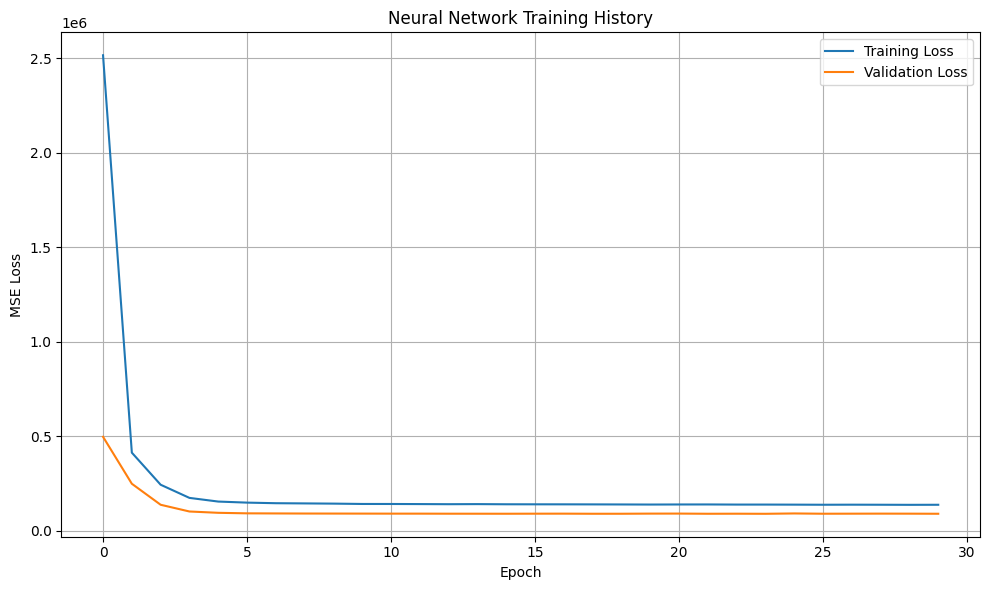

✓ Figure saved -> /content/drive/MyDrive/FitnessML_Master/figures/06_training_history.png


In [18]:
# ============================================================
# TRAINING HISTORY
# ============================================================

utils.section("Training history")

fig = plt.figure(figsize=(10, 6))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    valid_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Neural Network Training History")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
utils.save_figure(
    fig,
    "06_training_history.png"
)


In [19]:
# ============================================================
# NEURAL NETWORK EVALUATION
# ============================================================

utils.section("Neural network evaluation")

model.eval()

predictions = []

with torch.no_grad():

    for X_batch, _ in valid_loader:

        X_batch = X_batch.to(device)

        batch_predictions = model(
            X_batch
        )

        predictions.append(
            batch_predictions.cpu().numpy()
        )

y_pred_nn = np.concatenate(
    predictions
).ravel()

y_valid_eval = y_valid.to_numpy()

mae_nn = mean_absolute_error(
    y_valid_eval,
    y_pred_nn
)

rmse_nn = np.sqrt(
    mean_squared_error(
        y_valid_eval,
        y_pred_nn
    )
)

r2_nn = r2_score(
    y_valid_eval,
    y_pred_nn
)

neural_network_results = {
    "Model": "Neural Network",
    "MAE": mae_nn,
    "RMSE": rmse_nn,
    "R2": r2_nn
}

display(
    pd.DataFrame([
        neural_network_results
    ])
)


NEURAL NETWORK EVALUATION


,Model,MAE,RMSE,R2
0,Neural Network,239.978347,300.357974,-0.003123


In [21]:
# ============================================================
# MODEL COMPARISON
# ============================================================

utils.section("Model comparison")

# Load results from notebook 05
baseline_results = pd.read_csv(
    config.TABLES_DIR / "05_model_results.csv"
)

# Add current neural network result
all_model_results = pd.concat(
    [
        baseline_results,
        pd.DataFrame([
            neural_network_results
        ])
    ],
    ignore_index=True
)

all_model_results = (
    all_model_results
    .sort_values(by="RMSE")
    .reset_index(drop=True)
)

display(all_model_results)


MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Linear Regression,239.690599,299.904654,-0.000097
1,Linear Regression + Engineered,239.702469,299.922320,-0.000215
2,Neural Network,239.978347,300.357974,-0.003123
3,Random Forest,242.008414,302.821678,-0.019646
4,Decision Tree,349.345620,437.865736,-1.131855


In [23]:
# ============================================================
# SAVE FINAL MODEL RESULTS
# ============================================================

utils.section("Save final model results")

MODEL_RESULTS_FILE = (
    config.TABLES_DIR / "06_model_results.csv"
)

all_model_results.to_csv(
    MODEL_RESULTS_FILE,
    index=False
)

print(
    f"✓ Final model results saved -> "
    f"{MODEL_RESULTS_FILE}"
)


SAVE FINAL MODEL RESULTS
✓ Final model results saved -> /content/drive/MyDrive/FitnessML_Master/tables/06_model_results.csv


In [24]:
# ============================================================
# SAVE NEURAL NETWORK PREDICTIONS
# ============================================================

predictions_file = (
    config.TABLES_DIR / "06_neural_network_predictions.csv"
)

nn_predictions = pd.DataFrame({
    "actual": y_valid_eval,
    "predicted": y_pred_nn
})

nn_predictions.to_csv(
    predictions_file,
    index=False
)

print(
    f"✓ Neural network predictions saved -> "
    f"{predictions_file}"
)

✓ Neural network predictions saved -> /content/drive/MyDrive/FitnessML_Master/tables/06_neural_network_predictions.csv


In [25]:
# ============================================================
# NOTEBOOK COMPLETED
# ============================================================

utils.section("Neural network modeling completed")


NEURAL NETWORK MODELING COMPLETED
